# 시계열 데이터와 RNN의 구조 및 동작

---

## 1. 시계열 데이터란?

### 정의

- *시계열 데이터(time series data)**란 시간의 흐름에 따라 관측된 데이터를 의미함.

각 데이터 포인트는 특정 시간 간격을 기준으로 순차적으로 기록됨.

### 예시

| 시간 | 온도(℃) |
| --- | --- |
| 08:00 | 20.5 |
| 09:00 | 21.2 |
| 10:00 | 22.0 |
| ... | ... |

실제 예: 기온 변화, 주식 가격, 심전도(ECG) 신호, 웹사이트 트래픽

### 특징

- 순서가 중요: 데이터가 발생한 순서에 따라 의미가 달라짐
- 시간 의존성 존재: 과거 값이 현재 또는 미래 값에 영향을 줄 수 있음
- 주기성 또는 추세가 있음: 예를 들어, 계절성이나 장기적인 상승/하락 추세가 있음

---

## 2. 전통적인 인공 신경망의 한계

### 일반적인 신경망(MLP)의 구조

```

입력층 → 은닉층 → 출력층
```

각 입력은 독립적으로 처리되며, 이전 입력의 정보를 기억하지 않음

예: 문장 내 단어 간 관계나 시간 순서 반영이 어려움

### 시계열에 부적합한 이유

- 과거 정보를 반영하지 못함 → "기억"이 없음
- 예측 시 이전 데이터와의 연관성을 반영할 수 없음

---

## 3. 순환 신경망(RNN)의 도입

### RNN의 핵심 개념

- *RNN(Recurrent Neural Network)**은 입력 데이터의 순서를 고려하여, 과거 정보를 "기억"할 수 있는 구조를 가짐

**순환(recurrent)**이라는 이름처럼, 이전 상태의 출력을 현재 상태에 다시 입력함

### RNN의 기본 구조

```
시간 t-1       시간 t        시간 t+1
 x[t-1]         x[t]          x[t+1]
   ↓              ↓              ↓
 [입력] →→→ [입력] →→→ [입력]
   ↓              ↓              ↓
 [RNN 셀] →→→ [RNN 셀] →→→ [RNN 셀]
   ↓              ↓              ↓
  h[t-1]        h[t]           h[t+1]  (숨겨진 상태)

```

- $x[t]$: 시점 t의 입력
- $h[t]$: 시점 t의 은닉 상태(hidden state) → 과거 정보를 요약한 벡터
- 출력은 $h[t]$에 의존 → 이전 시점의 은닉 상태를 기반으로 현재 상태를 계산함

---

## 4. RNN의 동작 과정 (구체적인 수식과 함께)

### 은닉 상태 계산

수식: $h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$

- $h_t$: 현재 시점 t의 은닉 상태
- $x_t$: 현재 시점의 입력 벡터
- $h_{t-1}$: 이전 시점의 은닉 상태
- $W_{xh}, W_{hh}$: 가중치 행렬
- $b_h$: 편향 벡터
- $\tanh$: 비선형 활성화 함수

### 출력 계산

수식: $y_t = W_{hy} \cdot h_t + b_y$

- $y_t$: 시점 t의 출력
- $W_{hy}$: 은닉 상태에서 출력으로의 가중치
- $b_y$: 출력층 편향

---

## 5. RNN이 정보를 기억하는 방식

### 메커니즘 요약

$h[t]$는 $h[t−1]$을 포함하여 계산됨 → 이전 정보를 부분적으로 보존함

이로 인해 입력의 시간 순서를 학습할 수 있음

### 비유

사람의 기억처럼, 최근 들은 정보를 더 잘 기억하고, 오래된 정보는 희미해짐

하지만 이 기억은 완벽하지 않음 → 장기 의존성 문제 발생

## 6. RNN의 한계

### 장기 의존성 문제 (Vanishing Gradient Problem)

**문제 설명:**

RNN은 과거 정보를 현재에 전달하기 위해 은닉 상태를 계속 업데이트함

시간이 길어질수록 이전 정보가 점점 희미해짐

역전파(Backpropagation through time, BPTT) 과정에서 기울기(gradient)가 사라짐 또는 폭주함 → 학습이 잘 되지 않음

**수학적 요약:**

다수의 행렬 곱이 반복되면서

수식: $\frac{\partial h_t}{\partial h_{t-n}}$ 이 지수적으로 감소 → 과거 정보가 현재에 거의 전달되지 않음

---

### 기억의 한계

긴 문장, 긴 시계열, 복잡한 의존 구조를 학습하기에 부족함

---

## 7. LSTM (Long Short-Term Memory)

### 등장 배경

RNN의 장기 의존성 문제를 해결하기 위해 1997년 Hochreiter & Schmidhuber가 제안한 구조

"장기(long)"와 "단기(short)" 기억을 동시에 다룰 수 있음

---

### 주요 개념

| 구조 요소 | 역할 |
| --- | --- |
| 셀 상태(cell state) $C_t$ | 기억을 전달하는 경로. 정보가 손실 없이 흐름 |
| 은닉 상태(hidden state) $h_t$ | 출력과 다음 단계의 입력 역할 |
| 게이트(gate) 구조 | 정보를 선택적으로 기억하거나 버림 |

---

### 내부 구조와 수식

**입력 게이트**

수식: $i_t = \sigma(W_{xi} \cdot x_t + W_{hi} \cdot h_{t-1} + b_i)$

**망각 게이트 (Forget Gate)**

수식: $f_t = \sigma(W_{xf} \cdot x_t + W_{hf} \cdot h_{t-1} + b_f)$

**출력 게이트**

수식: $o_t = \sigma(W_{xo} \cdot x_t + W_{ho} \cdot h_{t-1} + b_o)$

**셀 상태 업데이트**

수식: $\tilde{C}*t = \tanh(W*{xc} \cdot x_t + W_{hc} \cdot h_{t-1} + b_c)$

수식: $C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t$

**은닉 상태 계산**

수식: $h_t = o_t \cdot \tanh(C_t)$

각 게이트는 "기억할 것", "잊을 것", "출력할 것"을 선택적으로 조절하여 기억의 흐름을 정밀하게 제어함

---

## 8. GRU (Gated Recurrent Unit)

### 간략화된 LSTM

2014년 Cho 등이 제안함

셀 상태 없이 오직 은닉 상태로만 정보 흐름을 조절함

LSTM보다 더 간단하고 빠르며, 성능은 유사하거나 더 나은 경우도 있음

---

### 주요 게이트

**리셋 게이트**

수식: $r_t = \sigma(W_{xr} \cdot x_t + W_{hr} \cdot h_{t-1})$

**업데이트 게이트**

수식: $z_t = \sigma(W_{xz} \cdot x_t + W_{hz} \cdot h_{t-1})$

**은닉 상태 후보 계산**

수식: $\tilde{h}*t = \tanh(W*{xh} \cdot x_t + r_t \cdot (W_{hh} \cdot h_{t-1}))$

**최종 은닉 상태**

수식: $h_t = (1 - z_t) \cdot h_{t-1} + z_t \cdot \tilde{h}_t$

- 업데이트 게이트 $z_t$는 이전 상태를 얼마나 유지할지를 결정함

- 리셋 게이트 $r_t$는 과거 정보를 얼마나 무시할지를 조절함

---

## RNN 계열 모델 학습 흐름 요약

| 단계 | 설명 |
| --- | --- |
| 1. 데이터 준비 | 시계열 데이터를 일정 구간(window) 단위로 자름 |
| 2. 데이터 정규화 | 값의 범위를 0~1 사이로 조정 (안정적 학습) |
| 3. 입력 차원 맞춤 | LSTM/GRU 입력 형식: (samples, timesteps, features) |
| 4. 모델 설계 | RNN → LSTM/GRU 선택 및 층 구성 |
| 5. 컴파일 및 학습 | 손실 함수(MSE 등), 옵티마이저 설정 후 학습 |
| 6. 예측 및 평가 | 테스트셋 예측 결과와 비교 |

---

## 정리

- RNN은 순차 데이터 처리에 강력한 도구임
- 기본 RNN은 장기 기억이 약해, LSTM/GRU 같은 개선 모델을 사용함
- 시계열 예측, 자연어 처리(NLP), 음성 인식 등 다양한 분야에 적용 가능함

---

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 1. 시계열 데이터 생성 (예: 단순한 증가하는 수열)
data = np.array([i for i in range(1, 21)])  # [1, 2, ..., 20]
window_size = 3  # 예측을 위해 몇 개의 과거 값을 사용할지

# 2. 입력 시퀀스(X)와 타겟 값(y) 생성
X = []
y = []
for i in range(len(data) - window_size):
    X.append(data[i:i + window_size])
    y.append(data[i + window_size])
X = np.array(X)
y = np.array(y)

# 3. RNN 입력 형식으로 변환: [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# 4. RNN 모델 구성
model = Sequential([
    SimpleRNN(32, activation='tanh', input_shape=(window_size, 1)),
    Dense(1)
])

# 5. 모델 컴파일 및 학습
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=200, verbose=0)

# 6. 예측
pred = model.predict(X)
print("예측 결과:", pred.flatten())

# 7. 비교 출력
for i in range(len(y)):
    print(f"입력: {X[i].flatten()} → 실제: {y[i]}, 예측: {pred[i][0]:.2f}")


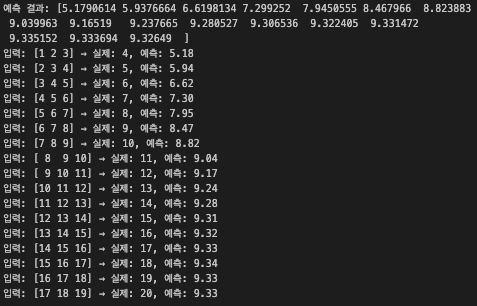